Dataset Name: Sentiment Labelled Sentences

Dataset Source: UCI Machine Learning Repository

Dataset Link: https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
amazon = pd.read_csv(
    '/content/amazon_cells_labelled.txt',
    sep='\t',
    header=None,
    names=['text', 'label']
)

imdb = pd.read_csv(
    '/content/imdb_labelled.txt',
    sep='\t',
    header=None,
    names=['text', 'label']
)

yelp = pd.read_csv(
    '/content/yelp_labelled.txt',
    sep='\t',
    header=None,
    names=['text', 'label']
)

print("Amazon:", amazon.shape)
print("IMDb:", imdb.shape)
print("Yelp:", yelp.shape)

Amazon: (1000, 2)
IMDb: (748, 2)
Yelp: (1000, 2)


In [4]:
df = pd.concat([amazon, imdb, yelp], ignore_index=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2748, 2)


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2748 non-null   object
 1   label   2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [6]:
df.isnull().sum()

,0
text,0
label,0


In [8]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 17


In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (2731, 2)
Duplicate rows: 0


The dataset contained 17 duplicate records, which were removed to avoid repeated observations. After removing duplicates, the dataset contains 2,731 unique records with no duplicate rows.

In [10]:
df['label'].value_counts()

,count
label,
1,1376
0,1355


In [11]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
1,50.384475
0,49.615525


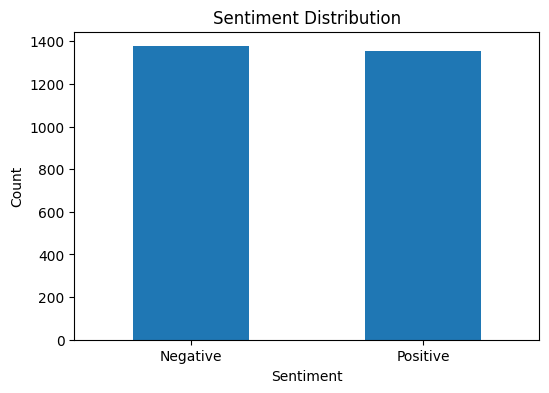

In [13]:
df['label'].value_counts().plot(kind='bar', figsize=(6, 4))

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.show()

The sentiment classes are almost evenly distributed, with 50.38% positive and 49.62% negative sentences. Therefore, the dataset is well balanced, and accuracy can be used as one of the useful evaluation metrics alongside precision, recall, and F1-score.

In [14]:
df['text_length'] = df['text'].str.len()

df['text_length'].describe()

,text_length
count,2731.000000
mean,71.831930
std,202.573197
min,7.000000
25%,33.000000
50%,56.000000
75%,87.000000
max,7944.000000


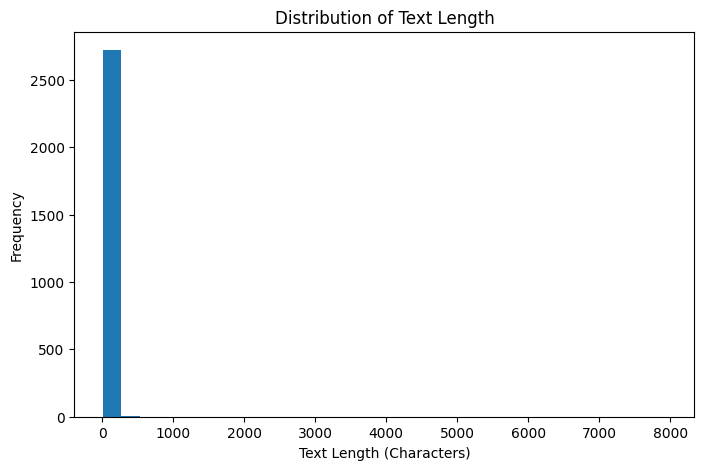

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df['text_length'], bins=30)

plt.title('Distribution of Text Length')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')

plt.show()

The text length varies considerably, with a median of 56 characters and a mean of 71.83 characters. Most texts are relatively short, but a small number of much longer texts create a right-skewed distribution. These longer texts were retained because they may contain valid information.

In [16]:
df.groupby('label')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1355.0,74.527675,255.772003,8.0,33.0,57.0,88.0,7944.0
1,1376.0,69.177326,130.539325,7.0,32.0,55.0,87.0,4487.0


Negative texts have a slightly higher average length than positive texts, but their median lengths are very similar. This suggests that text length alone is unlikely to strongly distinguish the two sentiment classes.

In [17]:
print("Empty texts:", (df['text'].str.strip() == '').sum())
print("Texts with fewer than 10 characters:", (df['text_length'] < 10).sum())

Empty texts: 0
Texts with fewer than 10 characters: 3


In [18]:
df[df['text_length'] < 10]

,text,label,text_length
1054,10/10,1,7
1091,Awful.,0,8
1284,See it.,1,9


Only three texts contain fewer than 10 characters, and all three are valid sentences or expressions with meaningful sentiment information. Therefore, no records were removed based on text length.

In [19]:
amazon['source'] = 'Amazon'
imdb['source'] = 'IMDb'
yelp['source'] = 'Yelp'

df = pd.concat([amazon, imdb, yelp], ignore_index=True)

df = df.drop_duplicates().reset_index(drop=True)

df['text_length'] = df['text'].str.len()

df.head()

,text,label,source,text_length
0,So there is no way for me to plug it in here i...,0,Amazon,82
1,"Good case, Excellent value.",1,Amazon,27
2,Great for the jawbone.,1,Amazon,22
3,Tied to charger for conversations lasting more...,0,Amazon,79
4,The mic is great.,1,Amazon,17


In [20]:
df['source'].value_counts()

,count
source,
Yelp,996
Amazon,990
IMDb,745


After removing duplicate records, the dataset contains 2,731 sentences from Amazon, IMDb, and Yelp. The three sources contribute a similar number of records, so no single source dominates the dataset.

In [21]:
pd.crosstab(df['source'], df['label'])

label,0,1
source,,
Amazon,497,493
IMDb,361,384
Yelp,497,499


In [22]:
pd.crosstab(
    df['source'],
    df['label'],
    normalize='index'
) * 100

label,0,1
source,,
Amazon,50.202020,49.797980
IMDb,48.456376,51.543624
Yelp,49.899598,50.100402


Sentiment is also well balanced within each source. Amazon and Yelp contain almost equal numbers of positive and negative texts, while IMDb has a slightly higher proportion of positive texts. Overall, no source shows a substantial sentiment imbalance.

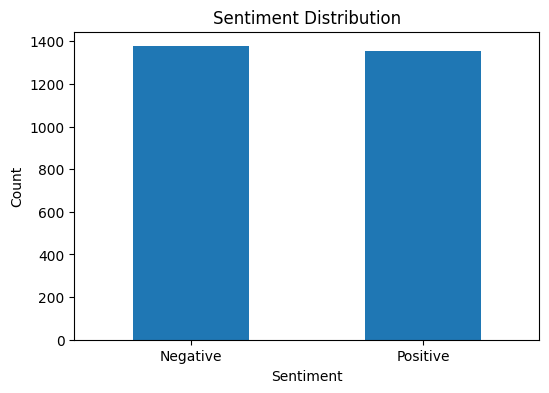

In [23]:
plt.figure(figsize=(6, 4))

df['label'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)

plt.show()

The dataset contains 1,355 negative and 1,376 positive sentences, showing that the two sentiment classes are almost evenly balanced.

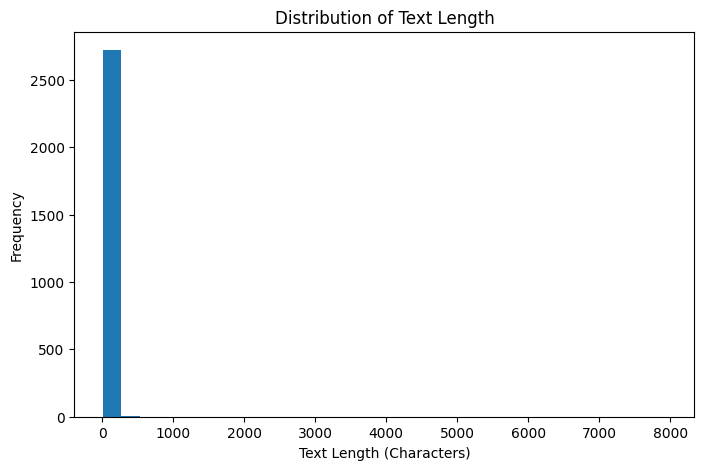

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df['text_length'], bins=30)

plt.title('Distribution of Text Length')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')

plt.show()

Most texts are relatively short, while a small number of much longer texts create a right-skewed distribution.

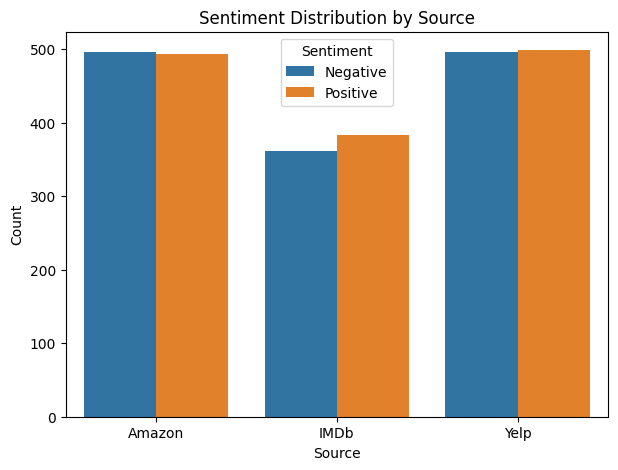

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='source', hue='label')

plt.title('Sentiment Distribution by Source')
plt.xlabel('Source')
plt.ylabel('Count')
plt.legend(title='Sentiment', labels=['Negative', 'Positive'])

plt.show()

The three sources contain similar numbers of positive and negative texts. This confirms that sentiment is relatively balanced not only overall but also within each source.

In [26]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head(10)

,text,clean_text
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great for the jawbone
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...
4,The mic is great.,the mic is great
5,I have to jiggle the plug to get it to line up...,i have to jiggle the plug to get it to line up...
6,If you have several dozen or several hundred c...,if you have several dozen or several hundred c...
7,If you are Razr owner...you must have this!,if you are razr owner you must have this
8,"Needless to say, I wasted my money.",needless to say i wasted my money
9,What a waste of money and time!.,what a waste of money and time


In [27]:
print("Missing cleaned texts:", df['clean_text'].isnull().sum())
print("Empty cleaned texts:", (df['clean_text'].str.strip() == '').sum())

Missing cleaned texts: 0
Empty cleaned texts: 0


In [28]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

negation_words = {'no', 'not', 'never', 'nor'}
stop_words = stop_words - negation_words

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['processed_text'] = df['clean_text'].apply(remove_stopwords)

df[['clean_text', 'processed_text']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,clean_text,processed_text
0,so there is no way for me to plug it in here i...,no way plug us unless go converter
1,good case excellent value,good case excellent value
2,great for the jawbone,great jawbone
3,tied to charger for conversations lasting more...,tied charger conversations lasting 45 minutes ...
4,the mic is great,mic great
5,i have to jiggle the plug to get it to line up...,jiggle plug get line right get decent volume
6,if you have several dozen or several hundred c...,several dozen several hundred contacts imagine...
7,if you are razr owner you must have this,razr owner must
8,needless to say i wasted my money,needless say wasted money
9,what a waste of money and time,waste money time


In [29]:
print("Original average length:",
      df['clean_text'].str.split().str.len().mean())

print("Processed average length:",
      df['processed_text'].str.split().str.len().mean())

Original average length: 13.387770047601611
Processed average length: 6.93006224826071


Stopword removal reduced the average text length from 13.39 words to 6.93 words. This removed common words while retaining more meaningful words for sentiment classification. Important negation words such as 'no', 'not', and 'never' were retained because they can affect sentiment.

In [30]:
df[['text', 'processed_text']].sample(5, random_state=42)

,text,processed_text
999,Loved the casting of Jimmy Buffet as the scien...,loved casting jimmy buffet science teacher
2028,I live in the neighborhood so I am disappointe...,live neighborhood disappointed back convenient...
1494,DELETE this film from your mind!,delete film mind
941,Very much disappointed with this company.,much disappointed company
73,Nice docking station for home or work.,nice docking station home work


In [31]:
from sklearn.model_selection import train_test_split

X = df['processed_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2184
Testing samples: 547


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (2184, 4304)
Testing TF-IDF shape: (547, 4304)


In [33]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 20 features:")
print(feature_names[:20])

Number of features: 4304
First 20 features:
['00' '10' '100' '11' '12' '13' '15' '15g' '15pm' '17' '18' '18th' '1928'
 '1947' '1948' '1949' '1971' '1973' '1979' '1980']


In [34]:
tfidf_scores = X_train_tfidf.sum(axis=0).A1

top_indices = np.argsort(tfidf_scores)[-20:][::-1]

print("Top 20 TF-IDF features:")
print(feature_names[top_indices])

Top 20 TF-IDF features:
['great' 'not' 'good' 'phone' 'food' 'service' 'movie' 'place' 'film'
 'bad' 'one' 'like' 'time' 'back' 'really' 'would' 'well' 'quality' 'go'
 'product']


TF-IDF generated 4,304 unique text features from the training data. Common sentiment-related words such as 'great', 'good', 'not', 'bad', and 'quality' received high overall TF-IDF scores, showing that the vectorizer captured meaningful words for sentiment classification.

In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred = lr_model.predict(X_test_tfidf)

print("Model training completed.")

Model training completed.


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8080
Precision: 0.8109
Recall   : 0.8080
F1-score : 0.8094


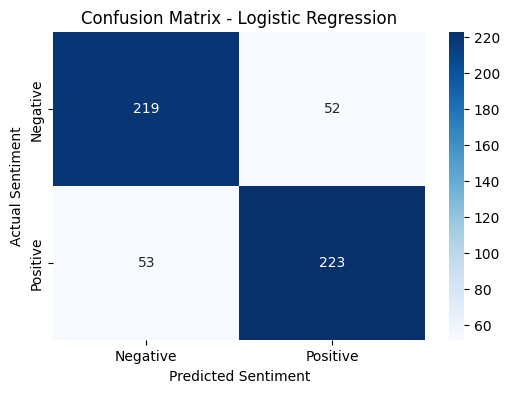

In [54]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

The confusion matrix shows that the model correctly classified 219 negative and 223 positive sentences. It made 52 false-positive and 53 false-negative predictions, showing that the errors were fairly balanced between the two sentiment classes.

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8853


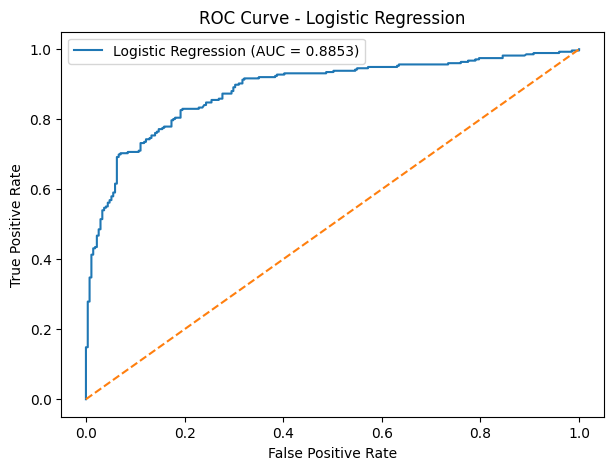

In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

The Logistic Regression model achieved a ROC-AUC score of 0.8853, indicating good separation between positive and negative sentiment classes. The ROC curve also shows that the model performs substantially better than random classification across different probability thresholds.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bigram = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf_bigram = tfidf_bigram.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf_bigram.shape)
print("Testing TF-IDF shape:", X_test_tfidf_bigram.shape)

Training TF-IDF shape: (2184, 15503)
Testing TF-IDF shape: (547, 15503)


In [41]:
lr_bigram = LogisticRegression(max_iter=1000)

lr_bigram.fit(X_train_tfidf_bigram, y_train)

y_pred_bigram = lr_bigram.predict(X_test_tfidf_bigram)

print("Bigram Logistic Regression training completed.")

Bigram Logistic Regression training completed.


In [50]:
accuracy_bigram = accuracy_score(y_test, y_pred_bigram)
precision_bigram = precision_score(y_test, y_pred_bigram)
recall_bigram = recall_score(y_test, y_pred_bigram)
f1_bigram = f1_score(y_test, y_pred_bigram)

y_prob_bigram = lr_bigram.predict_proba(X_test_tfidf_bigram)[:, 1]
roc_auc_bigram = roc_auc_score(y_test, y_prob_bigram)

print(f"Accuracy : {accuracy_bigram:.4f}")
print(f"Precision: {precision_bigram:.4f}")
print(f"Recall   : {recall_bigram:.4f}")
print(f"F1-score : {f1_bigram:.4f}")
print(f"ROC-AUC  : {roc_auc_bigram:.4f}")

Accuracy : 0.8026
Precision: 0.7958
Recall   : 0.8188
F1-score : 0.8071
ROC-AUC  : 0.8829


The unigram + bigram TF-IDF model achieved 80.26% accuracy and an F1-score of 80.71%, which was slightly lower than the unigram model. However, recall increased from 80.80% to 81.88%, showing that bigrams helped the model identify more positive sentences, although they did not improve the overall performance.

In [43]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM training completed.")

Linear SVM training completed.


In [51]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")

Accuracy : 0.8044
Precision: 0.7944
Recall   : 0.8261
F1-score : 0.8099


The Linear SVM achieved 80.44% accuracy and an F1-score of 80.99%. It produced higher recall than Logistic Regression, increasing from 80.80% to 82.61%, while its accuracy and precision were slightly lower. Overall, both models showed similar performance on the sentiment classification task.

In [45]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes training completed.")

Naive Bayes training completed.


In [52]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-score : {f1_nb:.4f}")

Accuracy : 0.7952
Precision: 0.7789
Recall   : 0.8297
F1-score : 0.8035


The three classification algorithms produced similar results, with accuracy ranging from 79.52% to 80.80%. Logistic Regression achieved the highest accuracy, precision, and ROC-AUC, while Naive Bayes achieved the highest recall. Linear SVM produced a similar F1-score to Logistic Regression, showing that the models have comparable overall performance.

In [47]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train_tfidf, y_train)

print("Best C:", grid_search.best_params_['C'])
print("Best Cross-Validation F1-score:", grid_search.best_score_)

Best C: 10
Best Cross-Validation F1-score: 0.8275228029174958


In [48]:
tuned_lr = LogisticRegression(C=10, max_iter=1000)

tuned_lr.fit(X_train_tfidf, y_train)

y_pred_tuned = tuned_lr.predict(X_test_tfidf)

print("Tuned Logistic Regression training completed.")

Tuned Logistic Regression training completed.


In [53]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

y_prob_tuned = tuned_lr.predict_proba(X_test_tfidf)[:, 1]
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1-score : {f1_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")

Accuracy : 0.8062
Precision: 0.8036
Recall   : 0.8152
F1-score : 0.8094
ROC-AUC  : 0.8869


Hyperparameter tuning selected C=10 based on 5-fold cross-validation. On the test set, the tuned Logistic Regression achieved 80.62% accuracy, 80.94% F1-score, and 88.69% ROC-AUC. Compared with the baseline model, the results were very similar, with a small improvement in ROC-AUC but slightly lower accuracy.

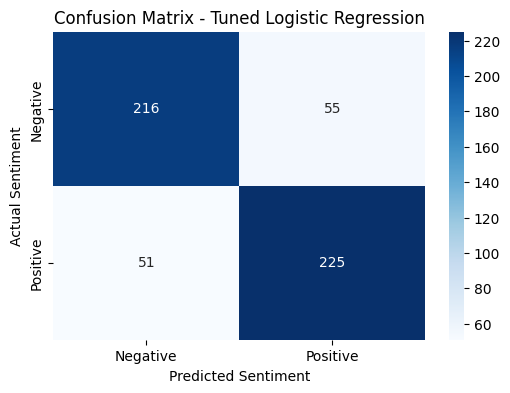

In [55]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

The tuned Logistic Regression correctly classified 216 negative and 225 positive sentences, with 55 false positives and 51 false negatives. The errors were relatively balanced between the two classes. Compared with the baseline model, tuning slightly changed the distribution of errors but did not produce a meaningful improvement in overall performance.

In [56]:
errors = df.loc[X_test.index].copy()

errors['predicted'] = y_pred_tuned

misclassified = errors[errors['label'] != errors['predicted']]

print("Misclassified texts:", len(misclassified))

misclassified[['text', 'label', 'predicted']].head(20)

Misclassified texts: 106


,text,label,predicted
2156,"On the ground, right next to our table was a l...",0,1
390,The picture resolution is far below what other...,0,1
2091,"Sadly, Gordon Ramsey's Steak is a place we sha...",0,1
1568,The result is a film that just don't look righ...,0,1
337,"It was an inexpensive piece, but I would still...",0,1
924,You get extra minutes so that you can carry ou...,1,0
1278,"Lifetime does not air it enough, so if anyone ...",1,0
939,I had to purchase a different case.,0,1
1056,My only problem is I thought the actor playing...,0,1
2504,* Both the Hot & Sour & the Egg Flower Soups w...,1,0


The tuned Logistic Regression model misclassified 106 of the 547 test sentences. Several errors involve context-dependent expressions, negation, indirect sentiment, sarcasm, and numerical ratings that are difficult for a basic TF-IDF representation to capture. This suggests that richer text representations or more advanced language models could be explored as future improvements.

In [57]:
X_clean = df['clean_text']
y = df['label']

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_clean))
print("Testing samples:", len(X_test_clean))

Training samples: 2184
Testing samples: 547


In [58]:
tfidf_clean = TfidfVectorizer()

X_train_clean_tfidf = tfidf_clean.fit_transform(X_train_clean)
X_test_clean_tfidf = tfidf_clean.transform(X_test_clean)

print("Training TF-IDF shape:", X_train_clean_tfidf.shape)
print("Testing TF-IDF shape:", X_test_clean_tfidf.shape)

Training TF-IDF shape: (2184, 4433)
Testing TF-IDF shape: (547, 4433)


In [59]:
lr_clean = LogisticRegression(max_iter=1000)

lr_clean.fit(X_train_clean_tfidf, y_train_clean)

y_pred_clean = lr_clean.predict(X_test_clean_tfidf)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [60]:
accuracy_clean = accuracy_score(y_test_clean, y_pred_clean)
precision_clean = precision_score(y_test_clean, y_pred_clean)
recall_clean = recall_score(y_test_clean, y_pred_clean)
f1_clean = f1_score(y_test_clean, y_pred_clean)

y_prob_clean = lr_clean.predict_proba(X_test_clean_tfidf)[:, 1]
roc_auc_clean = roc_auc_score(y_test_clean, y_prob_clean)

print(f"Accuracy : {accuracy_clean:.4f}")
print(f"Precision: {precision_clean:.4f}")
print(f"Recall   : {recall_clean:.4f}")
print(f"F1-score : {f1_clean:.4f}")
print(f"ROC-AUC  : {roc_auc_clean:.4f}")

Accuracy : 0.8062
Precision: 0.8058
Recall   : 0.8116
F1-score : 0.8087
ROC-AUC  : 0.8731


In [61]:
!pip install -q sentence-transformers

In [62]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Pretrained model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Pretrained model loaded.


In [63]:
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

print("Training embeddings shape:", X_train_embeddings.shape)
print("Testing embeddings shape:", X_test_embeddings.shape)

Batches:   0%|          | 0/69 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Training embeddings shape: (2184, 384)
Testing embeddings shape: (547, 384)


In [64]:
lr_embedding = LogisticRegression(max_iter=1000)

lr_embedding.fit(X_train_embeddings, y_train)

y_pred_embedding = lr_embedding.predict(X_test_embeddings)

print("Embedding-based Logistic Regression training completed.")

Embedding-based Logistic Regression training completed.


In [65]:
accuracy_embedding = accuracy_score(y_test, y_pred_embedding)
precision_embedding = precision_score(y_test, y_pred_embedding)
recall_embedding = recall_score(y_test, y_pred_embedding)
f1_embedding = f1_score(y_test, y_pred_embedding)

y_prob_embedding = lr_embedding.predict_proba(X_test_embeddings)[:, 1]
roc_auc_embedding = roc_auc_score(y_test, y_prob_embedding)

print(f"Accuracy : {accuracy_embedding:.4f}")
print(f"Precision: {precision_embedding:.4f}")
print(f"Recall   : {recall_embedding:.4f}")
print(f"F1-score : {f1_embedding:.4f}")
print(f"ROC-AUC  : {roc_auc_embedding:.4f}")

Accuracy : 0.8483
Precision: 0.8561
Recall   : 0.8406
F1-score : 0.8483
ROC-AUC  : 0.9351


The sentence embedding-based Logistic Regression model achieved 84.83% accuracy, 85.61% precision, 84.06% recall, 84.83% F1-score, and 93.51% ROC-AUC. Compared with the TF-IDF baseline, the model improved accuracy by about 4 percentage points and ROC-AUC by about 5 percentage points. This indicates that pretrained sentence embeddings captured useful semantic information that improved sentiment classification.

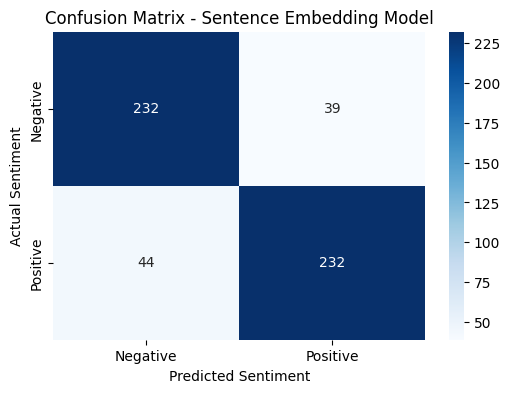

In [66]:
cm_embedding = confusion_matrix(y_test, y_pred_embedding)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_embedding,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix - Sentence Embedding Model')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

The sentence embedding model correctly classified 232 negative and 232 positive sentences, with 39 false positives and 44 false negatives. The errors are relatively balanced between the two sentiment classes, indicating that the model does not strongly favor one class. Compared with the tuned TF-IDF model, the embedding model produced fewer false positives and fewer false negatives, resulting in higher overall accuracy.

In [67]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression - TF-IDF',
        'Logistic Regression - TF-IDF Tuned',
        'Linear SVM - TF-IDF',
        'Multinomial Naive Bayes - TF-IDF',
        'Logistic Regression - Sentence Embeddings'
    ],
    'Accuracy': [
        0.8080,
        0.8062,
        0.8044,
        0.7952,
        0.8483
    ],
    'Precision': [
        0.8109,
        0.8036,
        0.7944,
        0.7789,
        0.8561
    ],
    'Recall': [
        0.8080,
        0.8152,
        0.8261,
        0.8297,
        0.8406
    ],
    'F1-score': [
        0.8094,
        0.8094,
        0.8099,
        0.8035,
        0.8483
    ],
    'ROC-AUC': [
        0.8853,
        0.8869,
        None,
        None,
        0.9351
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression - TF-IDF,0.8080,0.8109,0.8080,0.8094,0.8853
1,Logistic Regression - TF-IDF Tuned,0.8062,0.8036,0.8152,0.8094,0.8869
2,Linear SVM - TF-IDF,0.8044,0.7944,0.8261,0.8099,NaN
3,Multinomial Naive Bayes - TF-IDF,0.7952,0.7789,0.8297,0.8035,NaN
4,Logistic Regression - Sentence Embeddings,0.8483,0.8561,0.8406,0.8483,0.9351


The sentence embedding-based Logistic Regression model achieved the strongest overall performance among the tested models, with 84.83% accuracy, 84.83% F1-score, and 93.51% ROC-AUC. It improved accuracy by about 4 percentage points compared with the baseline TF-IDF Logistic Regression model and produced fewer classification errors. This suggests that pretrained sentence embeddings captured semantic information that was not fully represented by traditional TF-IDF features.

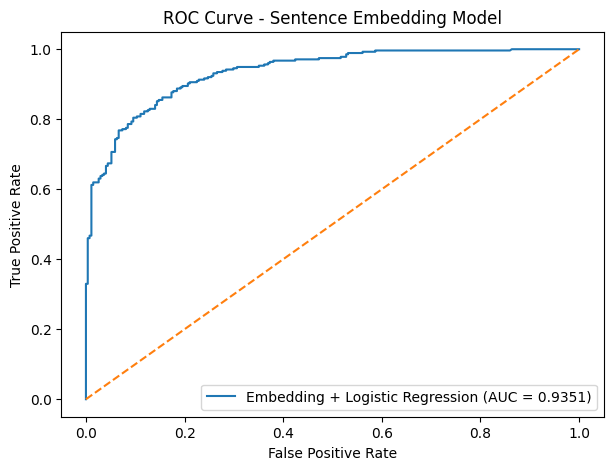

In [68]:
fpr_embedding, tpr_embedding, thresholds = roc_curve(
    y_test,
    y_prob_embedding
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_embedding,
    tpr_embedding,
    label=f'Embedding + Logistic Regression (AUC = {roc_auc_embedding:.4f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Sentence Embedding Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [69]:
y_prob_tuned = tuned_lr.predict_proba(X_test_tfidf)[:, 1]

roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Baseline TF-IDF AUC:", roc_auc)
print("Tuned TF-IDF AUC:", roc_auc_tuned)
print("Sentence Embedding AUC:", roc_auc_embedding)

Baseline TF-IDF AUC: 0.8852679287662442
Tuned TF-IDF AUC: 0.8868856623348841
Sentence Embedding AUC: 0.9350700572223113


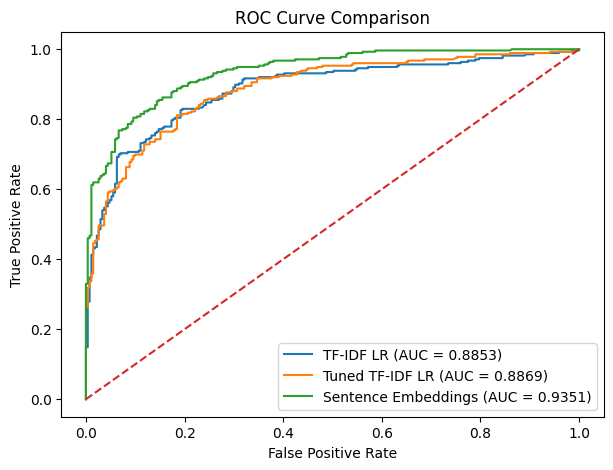

In [70]:
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_prob)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f'TF-IDF LR (AUC = {roc_auc:.4f})'
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f'Tuned TF-IDF LR (AUC = {roc_auc_tuned:.4f})'
)

plt.plot(
    fpr_embedding,
    tpr_embedding,
    label=f'Sentence Embeddings (AUC = {roc_auc_embedding:.4f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

The ROC-AUC comparison shows that the sentence embedding-based Logistic Regression model achieved the highest ROC-AUC of 93.51%, compared with 88.53% for the baseline TF-IDF model and 88.69% for the tuned TF-IDF model. Hyperparameter tuning produced only a small improvement in the TF-IDF model, while changing the text representation to pretrained sentence embeddings resulted in a much larger improvement. This indicates that semantic sentence representations provided better class separation than the traditional TF-IDF representation for this dataset.

In [71]:
import joblib

joblib.dump(
    lr_embedding,
    'sentiment_embedding_lr.pkl'
)

print("Logistic Regression model saved.")

Logistic Regression model saved.


In [72]:
embedding_model.save('sentence_embedding_model')

print("Sentence embedding model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Sentence embedding model saved.


In [73]:
loaded_lr = joblib.load('sentiment_embedding_lr.pkl')

test_prediction = loaded_lr.predict(X_test_embeddings[:5])

print("Predictions:", test_prediction)

Predictions: [1 0 1 1 1]


In [74]:
new_text = ["The food was absolutely amazing and the service was excellent."]

new_embedding = embedding_model.encode(new_text)

prediction = loaded_lr.predict(new_embedding)[0]

if prediction == 1:
    print("Prediction: Positive")
else:
    print("Prediction: Negative")

Prediction: Positive
